<a href="https://colab.research.google.com/github/alexiticoh/superstore-python-eda-rfm-segmentation/blob/main/Superstore_Customer_Segmentation_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Cargar dataset con codificación latin1
df = pd.read_csv("Sample_ Superstore.csv", encoding="latin1")

# Limpieza y parseo de fechas
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed")
df["Margin_%"] = (df["Profit"] / df["Sales"]) * 100

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head(3)

Dimensiones del dataset: 9994 filas y 20 columnas.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Margin_%
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,16.0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,30.0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,47.0


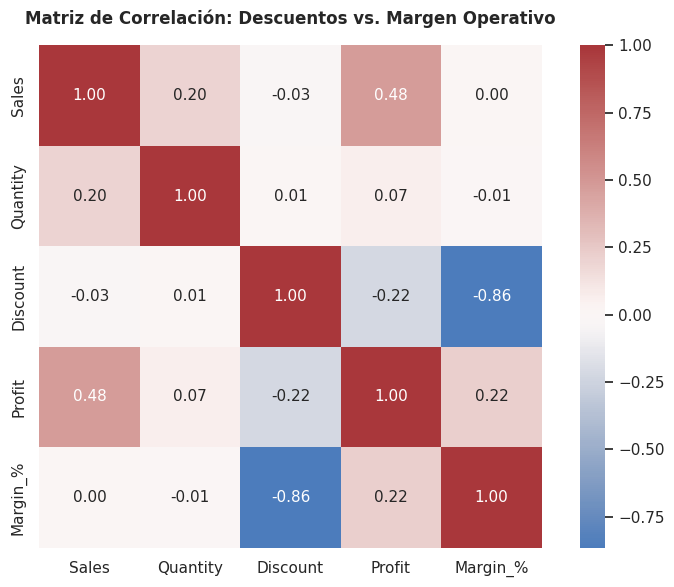

In [3]:
# Seleccionar variables numéricas clave
numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Margin_%"]
corr_matrix = df[numeric_cols].corr()

# Graficar Heatmap de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, cbar=True, square=True)
plt.title("Matriz de Correlación: Descuentos vs. Margen Operativo", pad=15, weight="bold")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1676/3310020971.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Discount_Tier", y="Profit", estimator=np.mean, ci=None, palette="RdYlGn_r")
/tmp/ipykernel_1676/3310020971.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Discount_Tier", y="Profit", estimator=np.mean, ci=None, palette="RdYlGn_r")


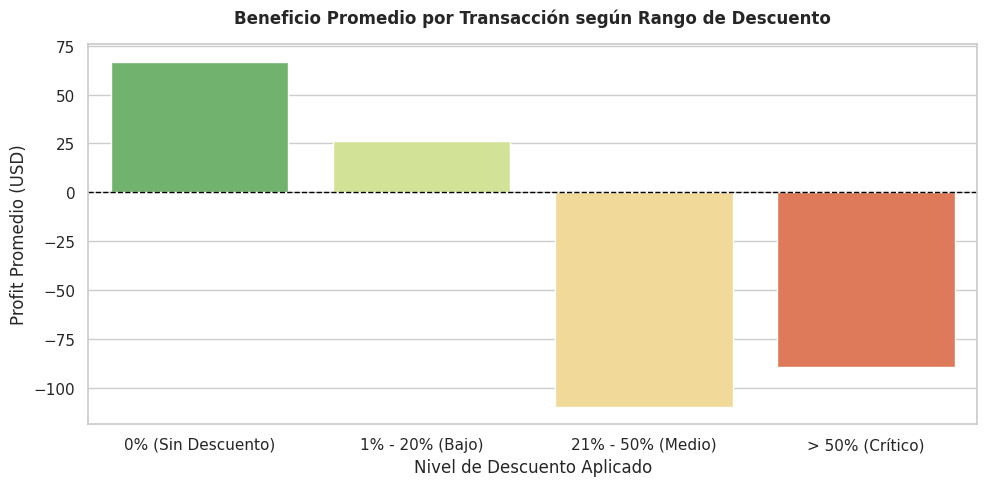

In [4]:
# Clasificar niveles de descuento
df["Discount_Tier"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0.0, 0.20, 0.50, 1.0],
    labels=["0% (Sin Descuento)", "1% - 20% (Bajo)", "21% - 50% (Medio)", "> 50% (Crítico)"]
)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Discount_Tier", y="Profit", estimator=np.mean, ci=None, palette="RdYlGn_r")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Beneficio Promedio por Transacción según Rango de Descuento", pad=15, weight="bold")
plt.xlabel("Nivel de Descuento Aplicado")
plt.ylabel("Profit Promedio (USD)")
plt.tight_layout()
plt.show()

In [5]:
# Fecha de referencia para el cálculo de Recency (un día posterior a la última orden)
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

# Construcción de la tabla RFM
rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (snapshot_date - x.max()).days,
    "Order ID": "nunique",
    "Sales": "sum",
    "Profit": "sum"
}).reset_index()

rfm.rename(columns={
    "Order Date": "Recency",
    "Order ID": "Frequency",
    "Sales": "Monetary",
    "Profit": "Total_Profit"
}, inplace=True)

# Asignar puntajes de 1 a 4 usando cuartiles
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1])  # Menor recencia = mejor puntaje
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4])

# Combinar scores
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

# Definir función de segmentación de negocio
def segment_customer(row):
    r, f, m = int(row["R_Score"]), int(row["F_Score"]), int(row["M_Score"])
    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 2 and f >= 2:
        return "Loyal Customers"
    elif r >= 3 and f < 2:
        return "New / Promising"
    elif r < 2 and f >= 3:
        return "At Risk"
    else:
        return "Hibernating / Lost"

rfm["Customer_Segment"] = rfm.apply(segment_customer, axis=1)

# Resumen de segmentos
segment_summary = rfm.groupby("Customer_Segment").agg(
    Customer_Count=("Customer ID", "count"),
    Avg_Recency_Days=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Total_Revenue=("Monetary", "sum"),
    Total_Profit=("Total_Profit", "sum")
).reset_index()

segment_summary["Profit_Margin_%"] = (segment_summary["Total_Profit"] / segment_summary["Total_Revenue"]) * 100
segment_summary = segment_summary.sort_values(by="Total_Revenue", ascending=False)
segment_summary.round(2)

,Customer_Segment,Customer_Count,Avg_Recency_Days,Avg_Frequency,Total_Revenue,Total_Profit,Profit_Margin_%
3,Loyal Customers,314,76.48,6.82,868209.01,99352.97,11.44
1,Champions,176,33.23,8.81,802935.47,92680.46,11.54
2,Hibernating / Lost,182,378.65,3.76,308324.95,36531.54,11.85
0,At Risk,49,319.12,7.88,197382.95,40716.26,20.63
4,New / Promising,72,38.78,3.42,120348.49,17115.80,14.22


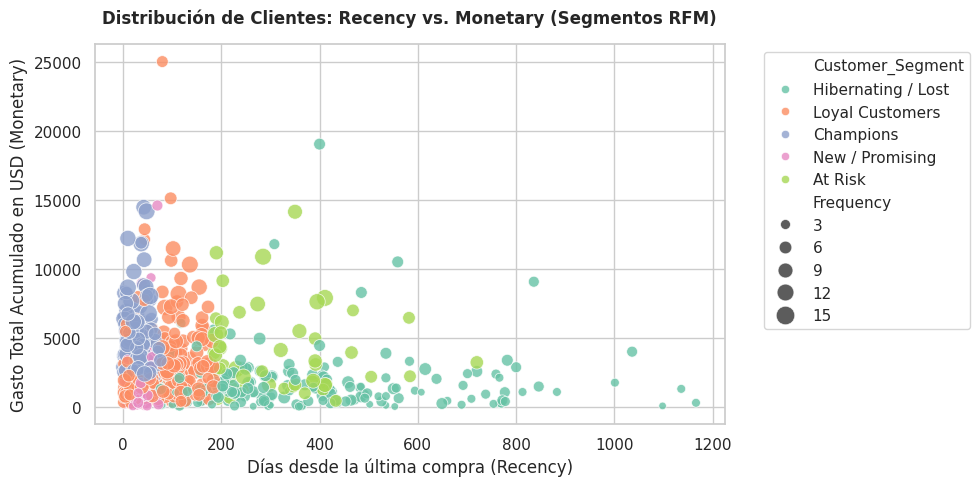

In [6]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Customer_Segment",
    size="Frequency",
    sizes=(30, 200),
    palette="Set2",
    alpha=0.8
)
plt.title("Distribución de Clientes: Recency vs. Monetary (Segmentos RFM)", pad=15, weight="bold")
plt.xlabel("Días desde la última compra (Recency)")
plt.ylabel("Gasto Total Acumulado en USD (Monetary)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()